# Demo: Multimodal Machine Learning on Spatial Transcriptomics

**Net4Brain Training School**

This notebook is the demonstration. We build a machine-learning pipeline on a
healthy human brain dataset, from raw tables to a biological interpretation.
You will then repeat the **same numbered sections** on a glioblastoma dataset
in `Try_GBM.ipynb`.

## Dataset: Healthy human cortex (DLPFC)

- **Gene expression**: 1,000 highly variable genes per spot, 10x Visium (measured)
- **Metabolic flux**: 168 metabolic module rates per spot, scFEA (inferred from the same expression data)

### Source
- **Gene Expression:** Maynard et al. (2021) *Transcriptome-scale spatial gene expression in the human
  dorsolateral prefrontal cortex.* Nature Neuroscience 24:425–436.
  <https://github.com/LieberInstitute/HumanPilot>
- **Flux inference:** Alghamdi et al. (2021) *A graph neural network model to estimate cell-wise
  metabolic flux using single cell RNA-seq data.* <https://github.com/changwn/scFEA>


# Day 1: Introduction & Preparing Data

Goal: understand the data before touching a model.


## 1.1 Setup


In [29]:
# On Google Colab, uncomment the next line once.
# !pip install -q scanpy shap

In [30]:
import warnings
warnings.filterwarnings("ignore")
import os, urllib
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 1

## 1.2 Download the data

Three tables describe the **same tissue spots**, in the same row order. That
shared row index is what makes this multimodal: for every spot we have both a
transcriptomic and a metabolic view.


In [31]:
DATA_DIR = "dataset"
BASE_URL = "https://raw.githubusercontent.com/Kaveh8/Workshop_Net4Brain/main/dataset"

FILES = ["dlpfc_gene_expression.csv.gz",
         "dlpfc_flux.csv.gz",
         "dlpfc_metadata.csv.gz",
         "scfea_module_info.csv"]

os.makedirs(DATA_DIR, exist_ok=True)
for fname in FILES:
    dest = os.path.join(DATA_DIR, fname)
    if os.path.exists(dest):
        print(f"already present: {fname}")
        continue
    print(f"downloading {fname} ...", end=" ", flush=True)
    urllib.request.urlretrieve(f"{BASE_URL}/{fname}", dest)
    print(f"{os.path.getsize(dest)/1e6:.1f} MB")


already present: dlpfc_gene_expression.csv.gz
already present: dlpfc_flux.csv.gz
already present: dlpfc_metadata.csv.gz
already present: scfea_module_info.csv


## 1.3 Loading the three tables


In [32]:
df_gene = pd.read_csv(f"{DATA_DIR}/dlpfc_gene_expression.csv.gz", index_col=0)
df_flux = pd.read_csv(f"{DATA_DIR}/dlpfc_flux.csv.gz", index_col=0)
df_meta = pd.read_csv(f"{DATA_DIR}/dlpfc_metadata.csv.gz", index_col=0)

print("gene expression :", df_gene.shape, " (spots x genes)")
print("metabolic flux  :", df_flux.shape, " (spots x modules)")
print("metadata        :", df_meta.shape, " (spots x descriptors)")

# The three tables must describe the same spots, in the same order.
print("same spot IDs:", df_gene.index.equals(df_meta.index) and df_flux.index.equals(df_meta.index))


gene expression : (12000, 1000)  (spots x genes)
metabolic flux  : (12000, 168)  (spots x modules)
metadata        : (12000, 7)  (spots x descriptors)
same spot IDs: True


### What is actually in each table?

Look at the numbers, not just the shapes. Expression values are already
**log-normalised**. We will not run `sc.pp.normalize` or `sc.pp.log1p`.


In [33]:
print("GENE EXPRESSION — log-normalised counts, one column per gene")
display(df_gene.iloc[:4, :6])

print("METABOLIC FLUX — one column per scFEA module")
display(df_flux.iloc[:4, :6])

print("METADATA — what we know about each spot independently of the measurements")
display(df_meta.head(4))

print("missing values:", int(df_gene.isna().sum().sum() + df_flux.isna().sum().sum()))
print("expression range: %.2f to %.2f" % (df_gene.values.min(), df_gene.values.max()))


GENE EXPRESSION — log-normalised counts, one column per gene


,SAMD11,ISG15,VWA1,AL031847.1,VAMP3,RBP7
151507_AAACAAGTATCTCCCA-1,0.0,1.3772,0.0,0.0,0.0,0.0
151507_AAACAATCTACTAGCA-1,0.0,0.0000,0.0,0.0,0.0,0.0
151507_AAACACCAATAACTGC-1,0.0,1.5226,0.0,0.0,0.0,0.0
151507_AAACAGCTTTCAGAAG-1,0.0,1.6917,0.0,0.0,0.0,0.0


METABOLIC FLUX — one column per scFEA module


,M_1,M_2,M_3,M_4,M_5,M_6
151507_AAACAAGTATCTCCCA-1,-0.000141,0.039663,0.060288,0.005242,0.000057,0.015459
151507_AAACAATCTACTAGCA-1,-0.000261,0.016715,0.017314,0.000195,0.000035,0.008592
151507_AAACACCAATAACTGC-1,-0.000247,0.018629,0.023479,0.000285,0.000037,0.008789
151507_AAACAGCTTTCAGAAG-1,-0.000230,0.026383,0.031251,0.001113,0.000042,0.009498


METADATA — what we know about each spot independently of the measurements


,sample_id,donor,layer,array_row,array_col,pxl_row,pxl_col
151507_AAACAAGTATCTCCCA-1,151507,Br5292,L3,50,102,8520,9178
151507_AAACAATCTACTAGCA-1,151507,Br5292,L1,3,43,2878,5133
151507_AAACACCAATAACTGC-1,151507,Br5292,WM,59,19,9581,3462
151507_AAACAGCTTTCAGAAG-1,151507,Br5292,L6,43,9,7663,2779


missing values: 0
expression range: 0.00 to 6.81


The metadata columns:

- `layer`: the expert annotation of which cortical layer the spot belongs to. This is our ground truth.
- `donor`: which of the three brains the spot came from. This becomes critical on Day 2.
- `sample_id`: which of the 12 tissue sections. Several sections come from each donor.
- `array_row`, `array_col`: position of the spot on the Visium grid, so we can plot results back onto the tissue.


### Where the fluxomic data come from

The only thing physically measured at each spot is mRNA. The flux table was
**computed from the gene expression** by [scFEA](https://github.com/changwn/scFEA)
(single-cell Flux Estimation Analysis), which we ran before the workshop.

Human central metabolism is written as a graph of metabolites and reactions.
scFEA collapses that graph into **168 modules**, each a short chain of consecutive
reactions, and maps each module to the genes encoding its enzymes. A small neural
network then predicts one flux value per module per spot. Its loss penalises
imbalance of intermediate metabolites, flow in must match flow out, which is
what makes the output more than a rescaled gene average.

`dataset/scfea_module_info.csv` is how we later turn `M_25` into a reaction name.


## 1.4 Pack the tables into AnnData

[AnnData](https://anndata.readthedocs.io) is the standard container in scanpy.
It holds the numbers (`X`), one row of metadata per spot (`obs`), and the
spatial coordinates (`obsm["spatial"]`). We make one object for genes and one
for flux.

We flip the y coordinate so the tissue is not upside-down.


In [34]:
adata = sc.AnnData(df_gene)
adata.obs = df_meta.copy()
adata.obsm["spatial"] = np.column_stack([adata.obs["array_col"], -adata.obs["array_row"]])

adata_flux = sc.AnnData(df_flux)
adata_flux.obs = adata.obs
adata_flux.obsm["spatial"] = adata.obsm["spatial"]

print(adata)
print(adata_flux)

AnnData object with n_obs × n_vars = 12000 × 1000
    obs: 'sample_id', 'donor', 'layer', 'array_row', 'array_col', 'pxl_row', 'pxl_col'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 12000 × 168
    obs: 'sample_id', 'donor', 'layer', 'array_row', 'array_col', 'pxl_row', 'pxl_col'
    obsm: 'spatial'


## 1.5 Exploratory data analysis

How much data do we have, what does the tissue look like, and do the
measurements agree with known biology?


### How much data do we have?


<Axes: title={'center': 'Spots per layer'}, xlabel='layer'>

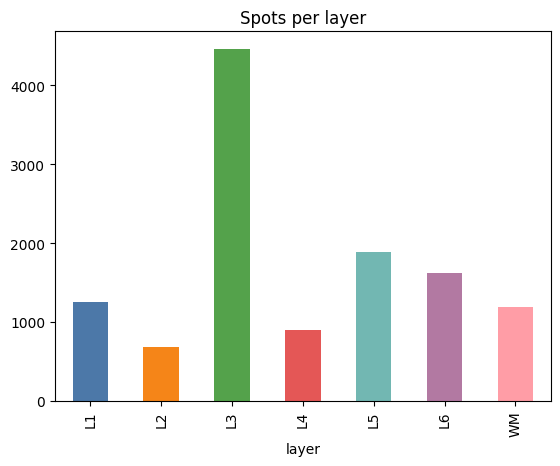

In [35]:
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2", "#FF9DA6"]
adata.obs["layer"].value_counts().sort_index().plot.bar(color=colors, title="Spots per layer")


<Axes: title={'center': 'Spots per donor'}, xlabel='donor'>

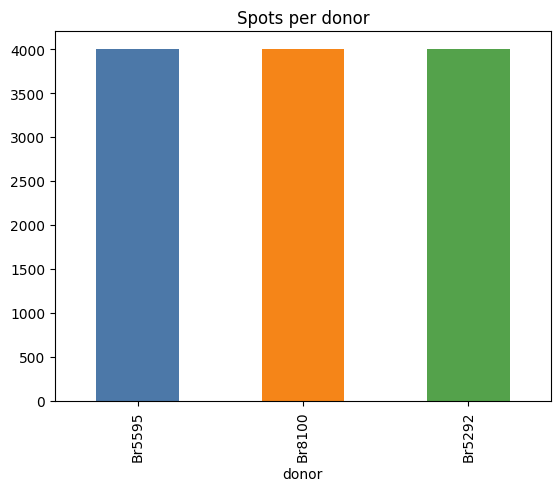

In [36]:
adata.obs["donor"].value_counts().plot.bar(color=["#4C78A8", "#F58518", "#54A24B"], title="Spots per donor")


<Axes: title={'center': 'Sections per donor'}, xlabel='donor'>

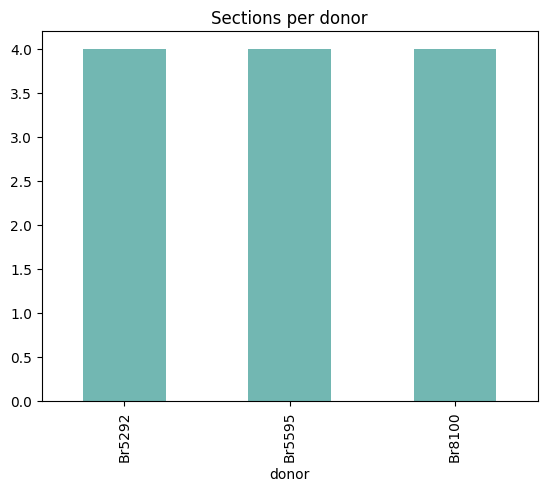

In [37]:
adata.obs.groupby("donor")["sample_id"].nunique().plot.bar(color="#72B7B2", title="Sections per donor")


### What does the tissue look like?

The layers form contiguous spatial bands. Neighbouring spots almost always
share a label.


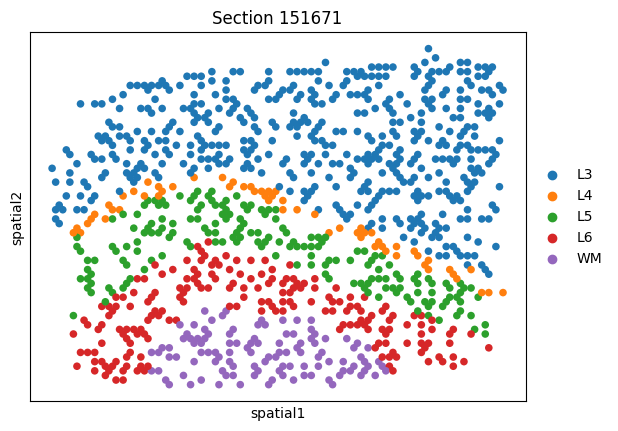

In [38]:
sec = adata.obs["sample_id"].value_counts().index[0]
sub = adata[adata.obs["sample_id"] == sec]
sc.pl.embedding(sub, basis="spatial", color="layer", title=f"Section {sec}")


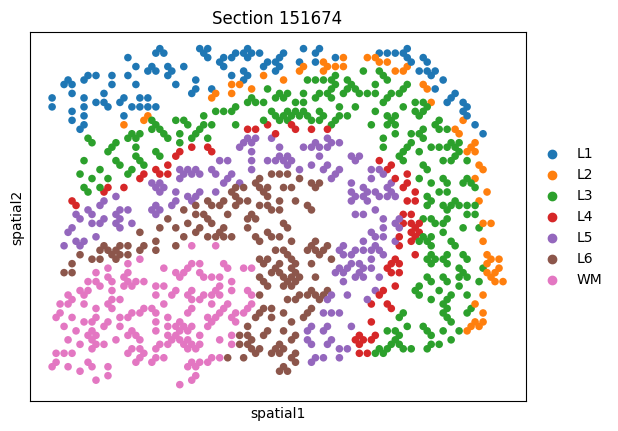

In [39]:
sec2 = adata.obs["sample_id"].value_counts().index[1]
sc.pl.embedding(adata[adata.obs["sample_id"] == sec2], basis="spatial",
                color="layer", title=f"Section {sec2}")


### Marker genes

A sanity check. If a known marker is in the wrong place, something is wrong
with the data.

- **MBP**, **MOBP** — myelin. Expect them high in white matter (`WM`).
- **RELN** — typically higher in upper cortex.


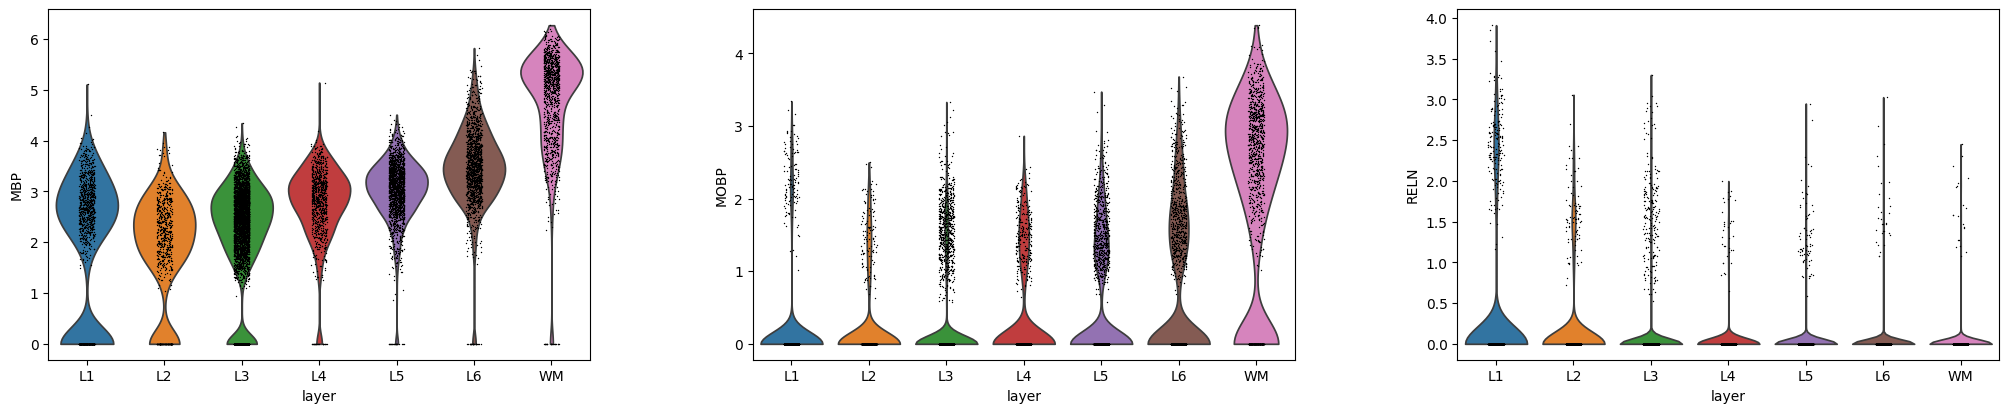

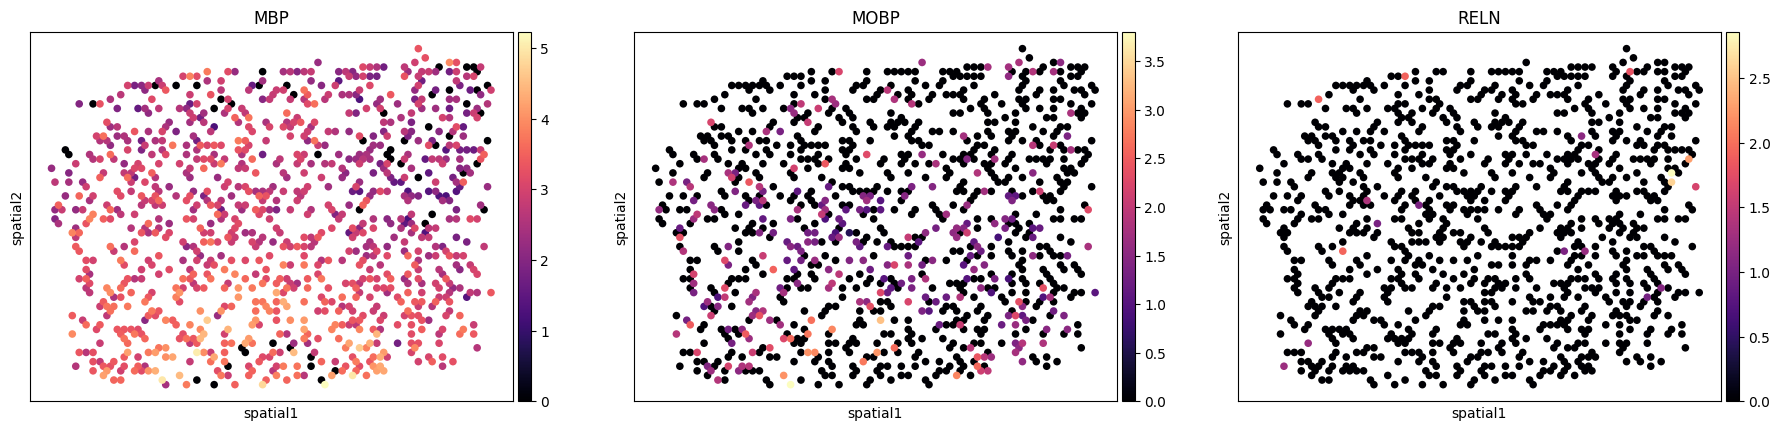

In [40]:
markers = ["MBP", "MOBP", "RELN"]
sc.pl.violin(adata, markers, groupby="layer")
sc.pl.embedding(sub, basis="spatial", color=markers, cmap="magma")


### Metabolic modules

Same idea as the genes: look at a few modules on the tissue. The table
`scfea_module_info.csv` turns an ID such as `M_2` into a reaction name.


     Compound_IN_name Compound_OUT_name
M_2               G6P               G3P
M_3               G3P               3PD
M_25      Glutathione         glutamate


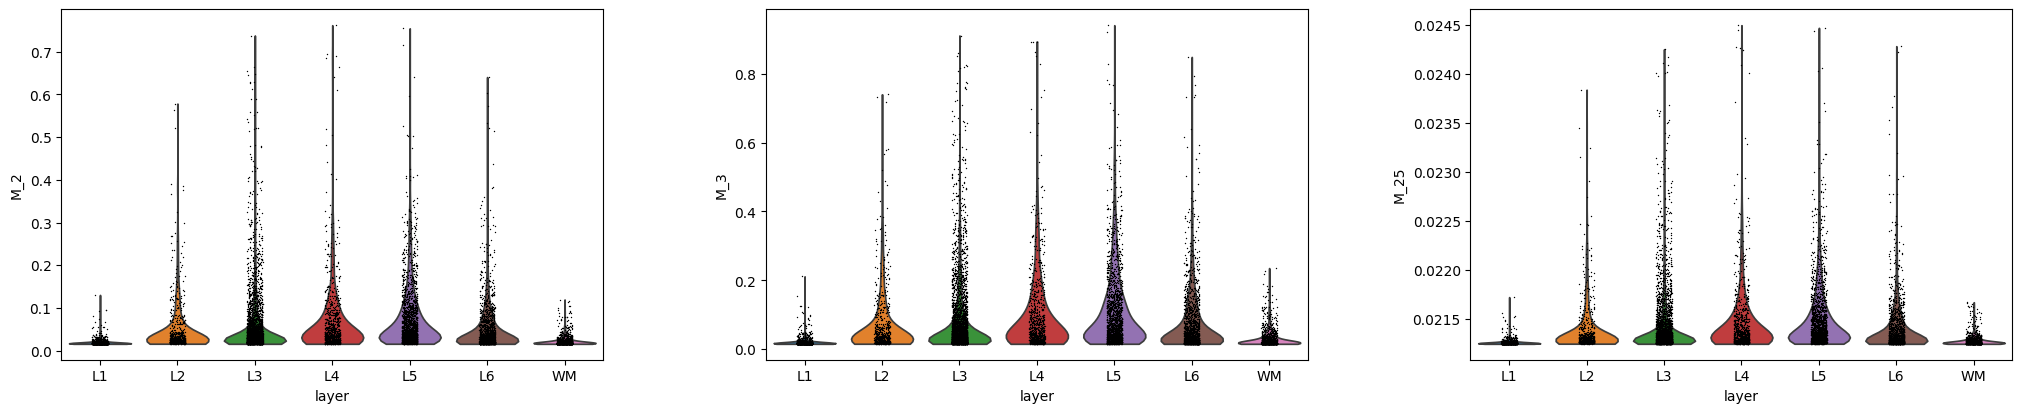

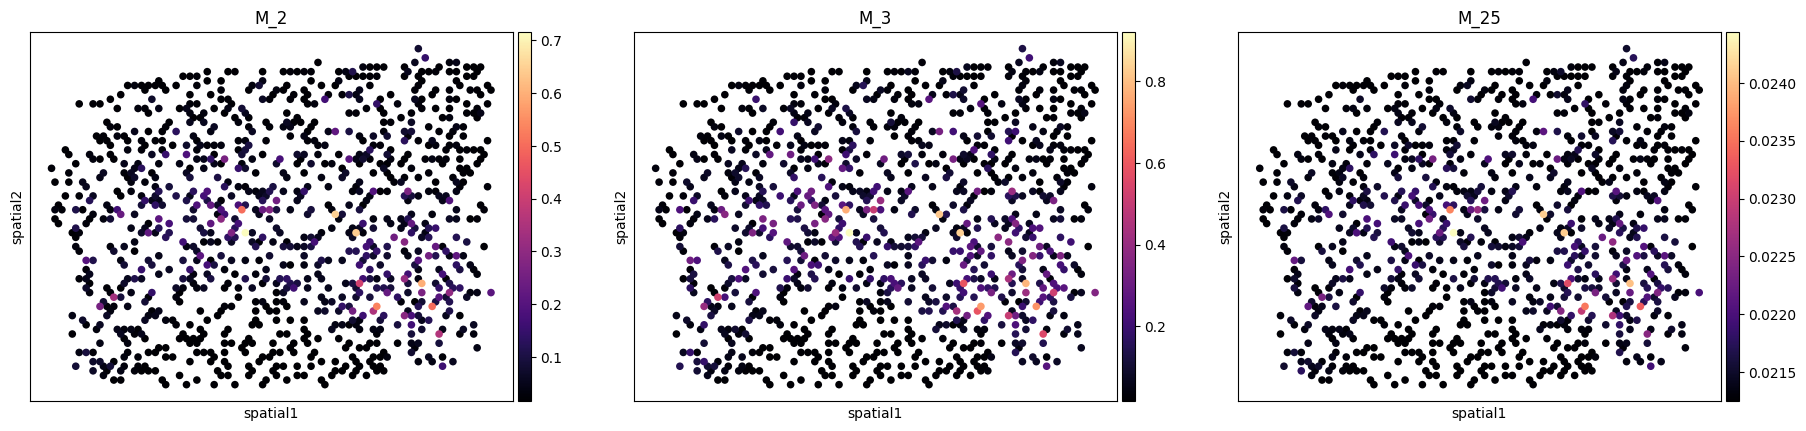

In [41]:
mod_info = pd.read_csv(f"{DATA_DIR}/scfea_module_info.csv", index_col=0)
mods = ["M_2", "M_3", "M_25"]
print(mod_info.loc[mods, ["Compound_IN_name", "Compound_OUT_name"]])

sc.pl.violin(adata_flux, mods, groupby="layer")
sc.pl.embedding(adata_flux[adata_flux.obs["sample_id"] == sec],
                basis="spatial", color=mods, cmap="magma")


## 1.6 Labels

We predict **Superficial (L1–L3)** vs **Deep (L4–L6)** and drop white matter.
`y` is the label; `groups` is the donor.


In [42]:
LAYER_GROUP = {"L1": "Superficial", "L2": "Superficial", "L3": "Superficial",
               "L4": "Deep",        "L5": "Deep",        "L6": "Deep"}

adata.obs["target"] = adata.obs["layer"].map(LAYER_GROUP)
keep = adata.obs["target"].notna()
adata = adata[keep].copy()
adata_flux = adata_flux[keep].copy()
df_gene = df_gene.loc[keep]
df_flux = df_flux.loc[keep]

y = adata.obs["target"]
groups = adata.obs["donor"]
print(y.value_counts().to_dict())
print("donors:", sorted(groups.unique()))


{'Superficial': 6401, 'Deep': 4406}
donors: ['Br5292', 'Br5595', 'Br8100']


---
# Day 2: Training models



In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


## 2.1 Train / test split


In [44]:
held_out = sorted(groups.unique())[0]
train = groups != held_out
test = groups == held_out

print("held-out donor:", held_out)
print("train spots:", int(train.sum()), "  test spots:", int(test.sum()))


held-out donor: Br5292
train spots: 7013   test spots: 3794


## 2.2 Train a classifier


In [45]:
scaler = StandardScaler()
X_train = scaler.fit_transform(df_gene.loc[train])
X_test = scaler.transform(df_gene.loc[test])

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y[train])
pred = model.predict(X_test)


## 2.3 Classification results


accuracy: 0.84

              precision    recall  f1-score   support

        Deep       0.75      0.68      0.71      1108
 Superficial       0.87      0.91      0.89      2686

    accuracy                           0.84      3794
   macro avg       0.81      0.79      0.80      3794
weighted avg       0.84      0.84      0.84      3794



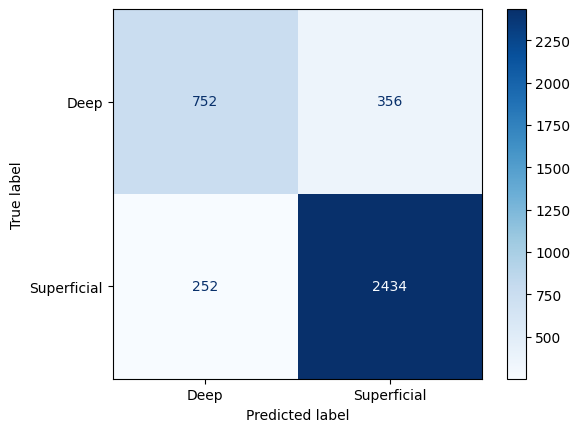

In [46]:
print("accuracy:", round(accuracy_score(y[test], pred), 3))
print()
print(classification_report(y[test], pred))
ConfusionMatrixDisplay.from_predictions(y[test], pred, cmap="Blues")


## 2.4 Compare modalities

Train the same classifier three ways on the same split: genes, flux, and both.


Gene expression    0.840
Metabolic flux     0.679
Both               0.835
dtype: float64
classes: ['Deep', 'Superficial']


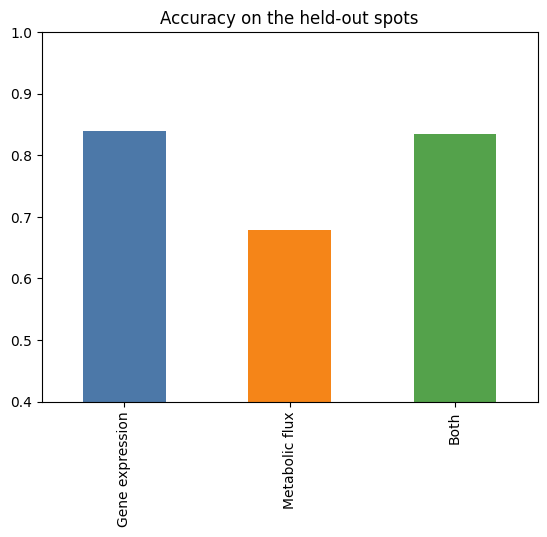

In [47]:
X_fused = pd.concat([df_gene, df_flux], axis=1)
X_fused = X_fused.loc[:, X_fused.loc[train].std() > 1e-5]

scores = {}
for name, X in [("Gene expression", df_gene),
                ("Metabolic flux", df_flux.loc[:, df_flux.loc[train].std() > 1e-5]),
                ("Both", X_fused)]:
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(scaler.fit_transform(X.loc[train]), y[train])
    pred = clf.predict(scaler.transform(X.loc[test]))
    scores[name] = accuracy_score(y[test], pred)

print(pd.Series(scores).round(3))
pd.Series(scores).plot.bar(ylim=(0.4, 1.0), color=["#4C78A8", "#F58518", "#54A24B"],
                           title="Accuracy on the held-out spots")

# keep the fused model for Day 3
X = X_fused
scaler = StandardScaler()
X_train = scaler.fit_transform(X.loc[train])
X_test = scaler.transform(X.loc[test])
feat_names = X.columns
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y[train])
print("classes:", list(model.classes_))


---
# Day 3: Explainable AI

We explain the fused model from 2.4.


## 3.1 SHAP

Each point is one spot. Colour is the feature value. Left / right is whether
that feature pushed the prediction toward one class or the other.


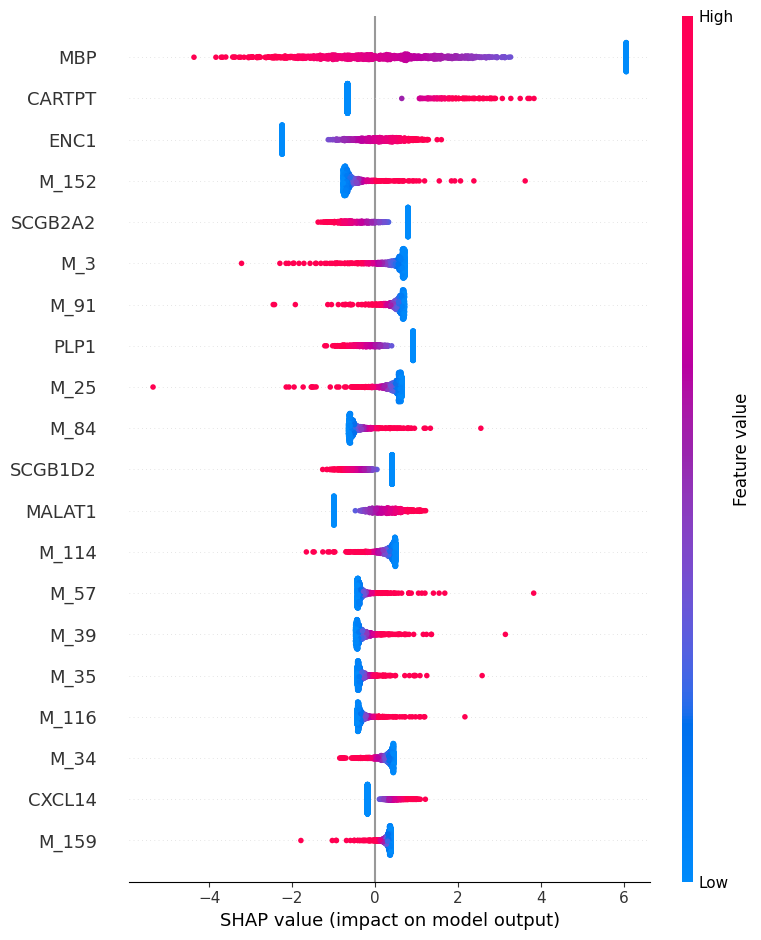

In [48]:
import shap

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test[:1000])
shap.summary_plot(shap_values, X_test[:1000], feature_names=list(feat_names))


## 3.2 Logistic coefficients

For a linear model the coefficient is the other explanation: how much the
prediction moves when that feature goes up.


positive class: Superficial (positive coefficient pushes toward this class)

MBP       2.091266
M_152     1.761783
M_84      1.392032
M_57      1.381226
M_25      1.319907
M_35      1.265824
M_34      1.242376
M_3       1.239104
M_116     1.159992
M_159     1.141021
M_166     1.128038
M_91      1.123621
CARTPT    1.037416
M_155     1.027220
M_148     0.984083
Name: |coefficient|, dtype: float64


<Axes: title={'center': 'Largest logistic coefficients'}>

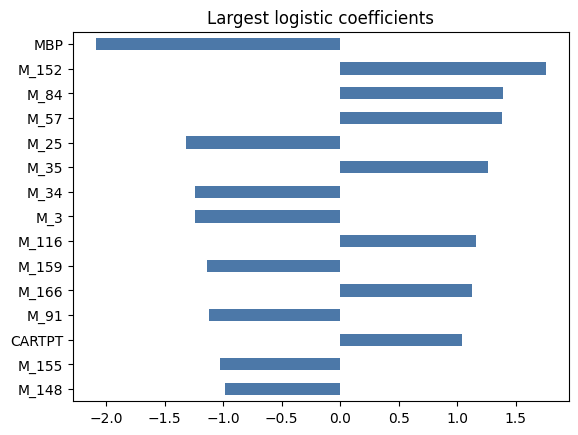

In [49]:
coef = pd.Series(model.coef_[0], index=feat_names)
print("positive class:", model.classes_[1], "(positive coefficient pushes toward this class)")
print()
print(coef.abs().sort_values(ascending=False).head(15).rename("|coefficient|"))

top = coef.reindex(coef.abs().sort_values(ascending=False).head(15).index)
top.iloc[::-1].plot.barh(color="#4C78A8", title="Largest logistic coefficients")


### Day 3

Look up two of the top genes on [GeneCards](https://www.genecards.org).
Then open `Try_GBM.ipynb` and repeat the same numbered sections.

`Periphery` on that dataset is not healthy tissue.


## How the flux values were generated

The flux tables are **not measured**. They were computed from the gene-expression
counts with [scFEA](https://github.com/changwn/scFEA) before the workshop. You
do not need to run this. It is here so you can see how the second modality
was produced.

```bash
git clone https://github.com/changwn/scFEA.git

# input: a genes x spots raw count matrix as CSV
python src/scFEA.py \
  --input_dir  <dir containing the count matrix> \
  --test_file  <counts.csv> \
  --moduleGene_file       module_gene_m168.csv \
  --stoichiometry_matrix  cmMat_c70_m168.csv \
  --cName_file            cName_c70_m168.csv \
  --sc_imputation True \
  --train_epoch 30 \
  --output_flux_file      <flux.csv>
```

`module_gene_m168.csv` maps genes to modules; `cmMat_c70_m168.csv` is the
stoichiometry matrix (70 compounds × 168 modules). The human M168 module set
was used for both datasets.
